# DSMarket — Task 3: 28-day sales forecasting

<div style="background-color:#2d8c4e;border-left:6px solid #2D8C4E;padding:14px;border-radius:10px">

**Notebook objective**

Build a demand forecasting system with a 28-day horizon
at **store × product × day** level, evaluate its quality against simple baselines,
and analyze whether the bottom-up approach is still valid for later aggregation
to higher business levels.

This notebook is the technical core of the project.

</div>

<a id="indice"></a>

## Table of Contents

1. [Setup and data loading](#setup)
2. [Panel construction and temporal split](#panel-split)
3. [E0a and E0b baselines](#baselines)
4. [Feature engineering for ML models](#features-ml)
5. [Training E1, E2 and E3 models](#modelos)
6. [Model diagnostics](#diagnostico)
7. [Calibration](#calibracion)
8. [Results export](#exportacion)
9. [Executive closing](#cierre)

## How to read this notebook

The workflow follows this sequence:

1. Build a long panel at store × product × day level.
2. Define a temporal split without leakage.
3. Compare the model against simple baselines.
4. Train a global model with LightGBM.
5. Analyze whether the technical improvement is sufficient from an operational perspective.

### Explicit business question

Paul, DSMarket's CFO, raises a key question:

> Is it still valid to forecast at the lowest level and then aggregate to obtain higher-level results?

The methodological answer of this notebook is:

**yes, the bottom-up approach remains valid**, as long as the model maintains sufficient quality
at store × product level and the later aggregation preserves useful business signal.

[⬆ Back to table of contents](#indice)

In [2]:
# =============================================================================
# Imports y configuración global
# =============================================================================

import os
import re
import gc
import warnings
from pathlib import Path
from tqdm.auto import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

COLORS = {
    "primary":   "#2D8C4E",
    "secondary": "#F4A261",
    "accent":    "#E76F51",
    "neutral":   "#8ECAE6",
    "dark":      "#264653",
}

FORECAST_HORIZON = 28

print(f"✅ Imports cargados | SEED={SEED} | Horizonte={FORECAST_HORIZON} días")

✅ Imports cargados | SEED=42 | Horizonte=28 días


<a id="setup"></a>

## Setup and data loading

This notebook is prepared to run across different environments,
as long as a folder with the base project files exists.

Product clustering will be loaded as an optional input:
it is only required if the **E3** experiment is to be executed.

**Practical note on Kaggle:**  
this initial block can run with normal RAM.  
Before building the long panel (`df_panel`), it is advisable to activate extended RAM mode.

[⬆ Back to table of contents](#indice)

In [3]:
# =============================================================================
# Rutas portables del proyecto
# =============================================================================

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR_DEFAULT = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, OUTPUTS_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

REQUIRED_FILES = {
    "daily_calendar_with_events.csv",
    "item_prices.csv",
    "item_sales.csv",
}

OPTIONAL_CLUSTER_FILES = [
    "product_clusters.csv",
    "clusters_productos.csv",
]

def has_required_files(folder: Path) -> bool:
    return folder.is_dir() and REQUIRED_FILES.issubset({p.name for p in folder.iterdir() if p.is_file()})

def build_candidate_raw_dirs() -> list[Path]:
    candidates = []

    env_raw = os.getenv("DSMARKET_RAW_DIR")
    if env_raw:
        candidates.append(Path(env_raw))

    candidates.extend([
        PROJECT_ROOT / "data" / "raw",
        PROJECT_ROOT / "raw",
        PROJECT_ROOT.parent / "data" / "raw",
        Path("/content/DSMarket/data/raw"),
        Path("/content/drive/MyDrive/TFM MASTER/TFM/Mateo/data/raw"),
        Path("/kaggle/input/dsmarket"),
        Path("/kaggle/input/datasets/mateopascual/dsmarket"),
    ])

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in kaggle_input.iterdir():
            if path.is_dir():
                candidates.append(path)
                candidates.extend([sub for sub in path.iterdir() if sub.is_dir()])

    unique_candidates = []
    seen = set()

    for path in candidates:
        path = Path(path)
        if str(path) not in seen:
            unique_candidates.append(path)
            seen.add(str(path))

    return unique_candidates

def resolve_raw_dir() -> Path:
    candidates = build_candidate_raw_dirs()

    for candidate in candidates:
        if has_required_files(candidate):
            return candidate
        if has_required_files(candidate / "data" / "raw"):
            return candidate / "data" / "raw"
        if has_required_files(candidate / "raw"):
            return candidate / "raw"

    searched = "\n - ".join(str(p) for p in candidates[:20])
    raise FileNotFoundError(
        "No se encontró una carpeta válida con los archivos requeridos.\n"
        "Archivos esperados:\n"
        f" - {chr(10).join(sorted(REQUIRED_FILES))}\n\n"
        "Puedes definir manualmente la variable de entorno DSMARKET_RAW_DIR.\n"
        f"Primeras rutas revisadas:\n - {searched}"
    )

RAW_DIR = resolve_raw_dir()

print("✅ RAW_DIR resuelto:", RAW_DIR)
print("✅ MODELS_DIR:", MODELS_DIR)
print("✅ PROCESSED_DIR:", PROCESSED_DIR)

✅ RAW_DIR resuelto: /kaggle/input/datasets/mateopascual/dsmarket
✅ MODELS_DIR: /kaggle/working/models
✅ PROCESSED_DIR: /kaggle/working/data/processed


In [4]:
# =============================================================================
# Localización opcional de clusters de producto
# =============================================================================

def resolve_optional_cluster_path() -> Path | None:
    candidates = []

    env_cluster = os.getenv("DSMARKET_CLUSTERS_PATH")
    if env_cluster:
        candidates.append(Path(env_cluster))

    candidates.extend([
        PROCESSED_DIR / "product_clusters.csv",
        PROCESSED_DIR / "clusters_productos.csv",
        OUTPUTS_DIR / "clustering_exports" / "clusters_productos.csv",
        PROJECT_ROOT / "csv para power bi" / "clusters_productos.csv",
        RAW_DIR / "product_clusters.csv",
    ])

    for candidate in candidates:
        if candidate.is_file():
            return candidate

    return None

CLUSTERS_PATH = resolve_optional_cluster_path()

if CLUSTERS_PATH is None:
    print("ℹ️ No se encontró archivo de clusters de producto.")
    print("ℹ️ El notebook podrá correr E0a, E0b, E1 y E2.")
    print("ℹ️ E3 quedará disponible solo si cargas después un CSV de clusters.")
else:
    print("✅ Clusters de producto encontrados en:", CLUSTERS_PATH)

ℹ️ No se encontró archivo de clusters de producto.
ℹ️ El notebook podrá correr E0a, E0b, E1 y E2.
ℹ️ E3 quedará disponible solo si cargas después un CSV de clusters.


In [5]:
# =============================================================================
# Carga de datos base
# =============================================================================

sales_dtypes = {
    "item": "category",
    "store_code": "category",
    "category": "category",
}

prices_dtypes = {
    "item": "category",
    "store_code": "category",
}

df_sales = pd.read_csv(
    RAW_DIR / "item_sales.csv",
    dtype=sales_dtypes,
    low_memory=False
)

df_prices = pd.read_csv(
    RAW_DIR / "item_prices.csv",
    dtype=prices_dtypes,
    low_memory=False
)

df_cal = pd.read_csv(
    RAW_DIR / "daily_calendar_with_events.csv",
    parse_dates=["date"],
    low_memory=False
)

print("✅ Datos base cargados")
print("df_sales :", df_sales.shape)
print("df_prices:", df_prices.shape)
print("df_cal   :", df_cal.shape)

✅ Datos base cargados
df_sales : (30490, 1920)
df_prices: (6965706, 5)
df_cal   : (1913, 5)


In [6]:
# =============================================================================
# Carga opcional de clusters de producto
# =============================================================================

df_clusters = None

if CLUSTERS_PATH is not None:
    df_clusters = pd.read_csv(CLUSTERS_PATH)
    print("✅ df_clusters cargado")
    print("Shape:", df_clusters.shape)
    display(df_clusters.head(3))
else:
    print("ℹ️ df_clusters = None")

ℹ️ df_clusters = None


In [7]:
# =============================================================================
# Validación inicial de estructura
# =============================================================================

required_sales = {"item", "store_code", "category"}
required_prices = {"item", "store_code", "sell_price", "yearweek"}
required_cal = {"date", "d"}

missing_sales = required_sales - set(df_sales.columns)
missing_prices = required_prices - set(df_prices.columns)
missing_cal = required_cal - set(df_cal.columns)

if missing_sales:
    raise ValueError(f"Faltan columnas en df_sales: {missing_sales}")

if missing_prices:
    raise ValueError(f"Faltan columnas en df_prices: {missing_prices}")

if missing_cal:
    raise ValueError(f"Faltan columnas en df_cal: {missing_cal}")

day_cols = [c for c in df_sales.columns if re.fullmatch(r"d_\d+", str(c))]
day_cols = sorted(day_cols, key=lambda x: int(str(x).split("_")[1]))

if not day_cols:
    raise ValueError("No se detectaron columnas diarias tipo d_1, d_2, ... en df_sales")

print("✅ Validación inicial completada")
print(f"Número de columnas diarias: {len(day_cols):,}")
print(f"Rango de días: {day_cols[0]} → {day_cols[-1]}")

display(df_sales.head(3))
display(df_prices.head(3))
display(df_cal.head(3))

✅ Validación inicial completada
Número de columnas diarias: 1,913
Rango de días: d_1 → d_1913


,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,...,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1


,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,328.0000",12.7414
1,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,329.0000",12.7414
2,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,330.0000",10.9858


,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN


<a id="panel-split"></a>

## Panel construction and temporal split

From this point onward, the heavy part of the notebook begins.

### Practical recommendation

- **If you are on Kaggle with normal RAM**, this is where it is advisable to stop and activate extended RAM.
- **If you are already on Kaggle with extended RAM**, you can continue.
- **If you are running locally**, this is the section with the highest memory risk.

Building `df_panel` in long format is the step that puts the most pressure on RAM,
because it transforms the wide sales history into a table at store × product × day level.

[⬆ Back to table of contents](#indice)

<a id="panel-split"></a>

## Panel construction and temporal split

From this point onward, the heavy part of the notebook begins.

### Practical recommendation

- **If you are on Kaggle with normal RAM**, this is where it is advisable to stop and activate extended RAM.
- **If you are already on Kaggle with extended RAM**, you can continue.
- **If you are running locally**, this is the section with the highest memory risk.

Building `df_panel` in long format is the step that puts the most pressure on RAM,
because it transforms the wide sales history into a table at store × product × day level.

[⬆ Back to table of contents](#indice)

In [8]:
# =============================================================================
# Fase 1 — Dataset panel: formato ancho → formato largo
# =============================================================================
# Propósito:
#   - Convertir df_sales a una fila por store × item × día
#   - Unir calendario para tener fecha real y variables temporales básicas
# Inputs:
#   - df_sales
#   - df_cal
# Outputs:
#   - df_panel: [store_code, item, category, d, units, date, weekday_int]
# Decisiones:
#   - melt sobre columnas d_* para pasar a formato largo
#   - join con df_cal por columna 'd'
#   - units se mantiene como ventas reales: no se imputan ceros
# =============================================================================

meta_cols = ["item", "store_code", "category"]

print("⏳ Transformando ventas a formato largo...")

df_panel = df_sales[meta_cols + day_cols].melt(
    id_vars=meta_cols,
    value_vars=day_cols,
    var_name="d",
    value_name="units"
)

df_cal_slim = df_cal.copy()

if "weekday_int" not in df_cal_slim.columns:
    df_cal_slim["weekday_int"] = df_cal_slim["date"].dt.weekday

keep_cal_cols = ["d", "date", "weekday_int"]
df_cal_slim = df_cal_slim[keep_cal_cols].copy()

df_panel = df_panel.merge(
    df_cal_slim,
    on="d",
    how="left"
)

df_panel["date"] = pd.to_datetime(df_panel["date"], errors="coerce")

df_panel["units"] = pd.to_numeric(df_panel["units"], errors="coerce").fillna(0).astype("int16")
df_panel["weekday_int"] = pd.to_numeric(df_panel["weekday_int"], errors="coerce").astype("int8")

df_panel = df_panel.sort_values(
    ["store_code", "item", "date"]
).reset_index(drop=True)

n_expected = df_sales.shape[0] * len(day_cols)
n_actual = len(df_panel)
n_null_units = int(df_panel["units"].isna().sum())
n_null_date = int(df_panel["date"].isna().sum())

print(f"✅ Filas esperadas: {n_expected:,}")
print(f"✅ Filas obtenidas: {n_actual:,}")
print(f"✅ Nulos en units:  {n_null_units:,}")
print(f"✅ Nulos en date:   {n_null_date:,}")
print(f"✅ Rango temporal:  {df_panel['date'].min()} → {df_panel['date'].max()}")
print(f"✅ Memoria:         {df_panel.memory_usage(deep=True).sum()/1e6:,.1f} MB")

display(df_panel.head(5))

gc.collect()

⏳ Transformando ventas a formato largo...
✅ Filas esperadas: 58,327,370
✅ Filas obtenidas: 58,327,370
✅ Nulos en units:  0
✅ Nulos en date:   0
✅ Rango temporal:  2011-01-29 00:00:00 → 2016-04-24 00:00:00
✅ Memoria:         4,049.4 MB


,item,store_code,category,d,units,date,weekday_int
0,ACCESORIES_1_001,BOS_1,ACCESORIES,d_1,0,2011-01-29,1
1,ACCESORIES_1_001,BOS_1,ACCESORIES,d_2,0,2011-01-30,2
2,ACCESORIES_1_001,BOS_1,ACCESORIES,d_3,0,2011-01-31,3
3,ACCESORIES_1_001,BOS_1,ACCESORIES,d_4,0,2011-02-01,4
4,ACCESORIES_1_001,BOS_1,ACCESORIES,d_5,0,2011-02-02,5


0

In [9]:
# =============================================================================
# Validación estructural del panel
# =============================================================================

required_panel = {"store_code", "item", "category", "d", "units", "date", "weekday_int"}
missing_panel = required_panel - set(df_panel.columns)

if missing_panel:
    raise ValueError(f"df_panel no tiene columnas requeridas: {missing_panel}")

null_dates = int(df_panel["date"].isna().sum())
if null_dates > 0:
    bad = df_panel.loc[df_panel["date"].isna(), "d"].head(10).tolist()
    raise ValueError(f"Hay fechas nulas en df_panel tras el merge con calendario. Ejemplos: {bad}")

dup_panel = df_panel.duplicated(subset=["store_code", "item", "date"]).sum()
if dup_panel > 0:
    raise ValueError(f"Hay duplicados en la clave (store_code, item, date): {dup_panel:,}")

print("✅ df_panel validado correctamente")
print("Tiendas únicas :", df_panel["store_code"].nunique())
print("Items únicos   :", df_panel["item"].nunique())
print("Categorías     :", df_panel["category"].nunique())

✅ df_panel validado correctamente
Tiendas únicas : 10
Items únicos   : 3049
Categorías     : 3


The temporal split must be defined **before** building the model features.

This avoids leakage and forces any lag, rolling or temporal variable
to be calculated respecting the true direction of time.

This notebook adopts the following logic:

- **final test** = last 28 days of the history,
- **train** = everything before that,
- **rolling validation** = 3 previous 28-day windows.

[⬆ Back to table of contents](#indice)

📅 Rango total:   2011-01-29 → 2016-04-24
📅 Train hasta:   2016-03-27
📅 Test:          2016-03-28 → 2016-04-24

📅 Ventanas de backtesting rolling:
   Ventana 1: 2016-01-04 → 2016-01-31
   Ventana 2: 2016-02-01 → 2016-02-28
   Ventana 3: 2016-02-29 → 2016-03-27

✅ Filas train: 57,473,650
✅ Filas test:  853,720


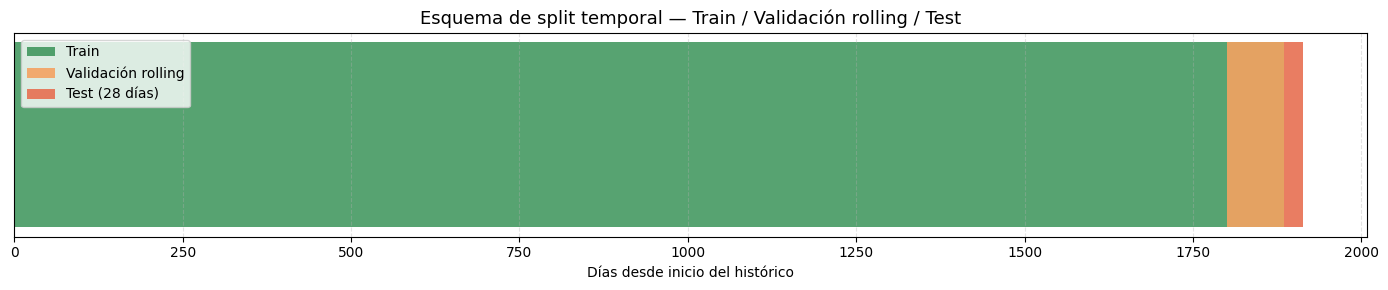


📌 Conclusión:
- Split temporal definido ANTES de construir features.
- 3 ventanas de backtesting rolling para validación robusta.
- No hay leakage: el test nunca entra en el train.


In [10]:
# =============================================================================
# Fase 1 — Split temporal
# =============================================================================
# Propósito:
#   - Definir períodos de train y test ANTES de construir features
#   - Evitar leakage: ninguna feature del futuro entra en el train
# Decisiones:
#   - Test: últimos 28 días del histórico
#   - Train: todo lo anterior
#   - Validación rolling: 3 ventanas de 28 días antes del test final
# =============================================================================

min_date   = df_panel["date"].min()
max_date   = df_panel["date"].max()
test_start = max_date - pd.Timedelta(days=FORECAST_HORIZON - 1)
train_end  = test_start - pd.Timedelta(days=1)

# Ventanas de backtesting rolling (3 ventanas de 28 días)
val_windows = []
for i in range(1, 4):
    v_end   = train_end - pd.Timedelta(days=FORECAST_HORIZON * (i - 1))
    v_start = v_end - pd.Timedelta(days=FORECAST_HORIZON - 1)
    val_windows.append((v_start, v_end))

val_windows = val_windows[::-1]

print(f"📅 Rango total:   {min_date.date()} → {max_date.date()}")
print(f"📅 Train hasta:   {train_end.date()}")
print(f"📅 Test:          {test_start.date()} → {max_date.date()}")

print("\n📅 Ventanas de backtesting rolling:")
for i, (v_start, v_end) in enumerate(val_windows, start=1):
    print(f"   Ventana {i}: {v_start.date()} → {v_end.date()}")

# Máscaras
is_train = df_panel["date"] <= train_end
is_test  = df_panel["date"] >= test_start

print(f"\n✅ Filas train: {is_train.sum():,}")
print(f"✅ Filas test:  {is_test.sum():,}")

# Gráfico visual del split
fig, ax = plt.subplots(figsize=(14, 3))

ax.barh(
    0,
    (train_end - min_date).days + 1,
    left=0,
    height=0.4,
    color=COLORS["primary"],
    alpha=0.8,
    label="Train"
)

for i, (v_start, v_end) in enumerate(val_windows):
    left  = (v_start - min_date).days
    width = (v_end - v_start).days + 1
    ax.barh(
        0,
        width,
        left=left,
        height=0.4,
        color=COLORS["secondary"],
        alpha=0.9,
        label="Validación rolling" if i == 0 else ""
    )

left_test = (test_start - min_date).days
ax.barh(
    0,
    FORECAST_HORIZON,
    left=left_test,
    height=0.4,
    color=COLORS["accent"],
    alpha=0.9,
    label=f"Test ({FORECAST_HORIZON} días)"
)

ax.set_xlabel("Días desde inicio del histórico")
ax.set_yticks([])
ax.set_title("Esquema de split temporal — Train / Validación rolling / Test", fontsize=13)
ax.legend(loc="upper left")
ax.grid(True, linestyle="--", alpha=0.35, axis="x")

plt.tight_layout()
plt.show()

print("\n📌 Conclusión:")
print("- Split temporal definido ANTES de construir features.")
print("- 3 ventanas de backtesting rolling para validación robusta.")
print("- No hay leakage: el test nunca entra en el train.")

In [11]:
# =============================================================================
# Fase 2 — Feature engineering: lags para baselines y modelo
# =============================================================================
# Propósito:
#   - Construir lags 7, 14, 21, 28 para cada store×item
#   - Estos lags son la base de los baselines E0a y E0b
#   - También serán features del modelo LightGBM
# Inputs:
#   - df_panel (store_code, item, date, units)
# Outputs:
#   - df_panel con columnas lag_7, lag_14, lag_21, lag_28 añadidas
# Decisiones:
#   - shift dentro de cada grupo store×item (no mezclar series)
#   - Los primeros 28 días de cada serie tendrán NaN en los lags
#   - Eso es correcto: no tenemos historia suficiente para calcularlos
# =============================================================================

print("⏳ Calculando lags por store×item...")

df_panel = df_panel.sort_values(["store_code", "item", "date"]).reset_index(drop=True)

for lag in [7, 14, 21, 28]:
    df_panel[f"lag_{lag}"] = (
        df_panel.groupby(["store_code", "item"], observed=True)["units"]
        .shift(lag)
        .astype("float32")
    )

lag_cols = ["lag_7", "lag_14", "lag_21", "lag_28"]

df_panel["lag_mean_7_14_21_28"] = (
    df_panel[lag_cols]
    .mean(axis=1)
    .astype("float32")
)

print(f"✅ Lags calculados: {lag_cols} + ['lag_mean_7_14_21_28']")

print(f"\n📊 NaNs por lag (esperado: primeros días de cada serie):")
for col in lag_cols:
    n_nan = df_panel[col].isna().sum()
    pct = n_nan / len(df_panel) * 100
    print(f"   {col}: {n_nan:,} NaNs ({pct:.2f}%)")

print("\n📊 Muestra con lags:")
display(
    df_panel[
        ["store_code", "item", "date", "units"] + lag_cols + ["lag_mean_7_14_21_28"]
    ].head(5)
)

print("\n📌 Conclusión:")
print("- Lags calculados correctamente dentro de cada serie store×item.")
print("- NaNs en los primeros días son esperados y correctos.")
print("- No hay leakage: lag_7 en fecha T usa ventas de T-7.")

⏳ Calculando lags por store×item...
✅ Lags calculados: ['lag_7', 'lag_14', 'lag_21', 'lag_28'] + ['lag_mean_7_14_21_28']

📊 NaNs por lag (esperado: primeros días de cada serie):
   lag_7: 213,430 NaNs (0.37%)
   lag_14: 426,860 NaNs (0.73%)
   lag_21: 640,290 NaNs (1.10%)
   lag_28: 853,720 NaNs (1.46%)

📊 Muestra con lags:


,store_code,item,date,units,lag_7,lag_14,lag_21,lag_28,lag_mean_7_14_21_28
0,BOS_1,ACCESORIES_1_001,2011-01-29,0,NaN,NaN,NaN,NaN,NaN
1,BOS_1,ACCESORIES_1_001,2011-01-30,0,NaN,NaN,NaN,NaN,NaN
2,BOS_1,ACCESORIES_1_001,2011-01-31,0,NaN,NaN,NaN,NaN,NaN
3,BOS_1,ACCESORIES_1_001,2011-02-01,0,NaN,NaN,NaN,NaN,NaN
4,BOS_1,ACCESORIES_1_001,2011-02-02,0,NaN,NaN,NaN,NaN,NaN



📌 Conclusión:
- Lags calculados correctamente dentro de cada serie store×item.
- NaNs en los primeros días son esperados y correctos.
- No hay leakage: lag_7 en fecha T usa ventas de T-7.


In [12]:
# =============================================================================
# Helper de métricas para baselines en test
# =============================================================================

def calc_metrics(y_true, y_pred, model_name):
    """Calcula métricas técnicas y de negocio para forecasting."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true + 1e-9) * 100
    bias = np.sum(y_pred - y_true) / np.sum(y_true + 1e-9) * 100
    underforecast_rate = np.mean(y_pred < y_true) * 100

    return {
        "model":             model_name,
        "MAE":               round(mae, 4),
        "RMSE":              round(rmse, 4),
        "WAPE (%)":          round(wape, 2),
        "Bias (%)":          round(bias, 2),
        "Underforecast (%)": round(underforecast_rate, 2),
    }

✅ Filas de test para evaluación: 853,720

📊 Métricas de baselines en período de test:


,model,MAE,RMSE,WAPE (%),Bias (%),Underforecast (%)
0,E0a — Lag 7,1.2054,2.6601,86.9400,0.1800,26.3600
1,E0b — Media lags 7-28,1.0463,2.1880,75.4600,-0.6400,29.7100


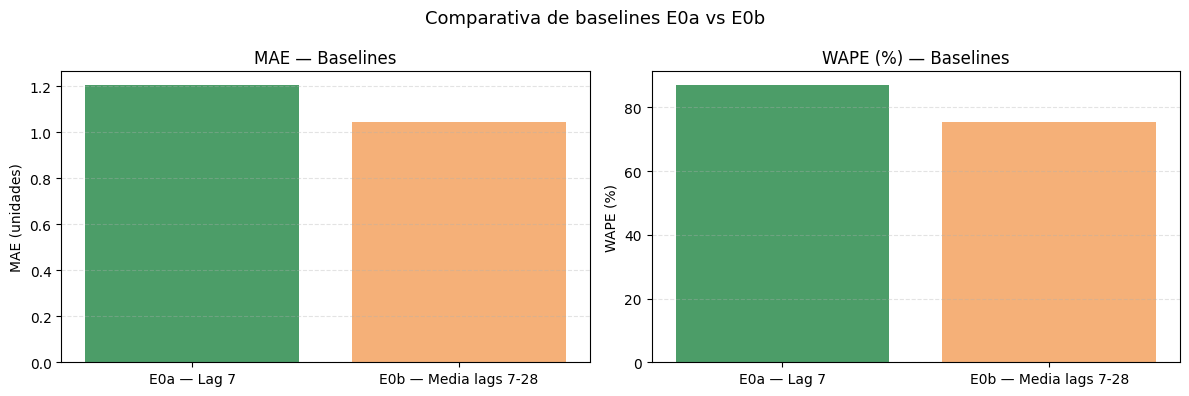


📌 Conclusión:
- Estos son los errores de referencia en el período final de test.
- El modelo LightGBM tiene que superar estos números para justificarse.
- Referencia principal: MAE baseline = 1.0463 unidades/día


In [13]:
# =============================================================================
# Fase 2 — Baselines E0a y E0b en período de test
# =============================================================================
# Propósito:
#   - E0a: lag_7 como predicción (seasonal naive)
#   - E0b: media de lag_7, lag_14, lag_21, lag_28
#   - Calcular métricas oficiales de comparación en test final
# =============================================================================

df_test = df_panel[is_test].copy()

df_test["pred_E0a"] = df_test["lag_7"]
df_test["pred_E0b"] = df_test[["lag_7", "lag_14", "lag_21", "lag_28"]].mean(axis=1)

df_eval = df_test.dropna(subset=["pred_E0a", "pred_E0b", "units"]).copy()

print(f"✅ Filas de test para evaluación: {len(df_eval):,}")

y_true = df_eval["units"].values

metrics = [
    calc_metrics(y_true, df_eval["pred_E0a"].values, "E0a — Lag 7"),
    calc_metrics(y_true, df_eval["pred_E0b"].values, "E0b — Media lags 7-28"),
]

df_metrics_baseline_test = pd.DataFrame(metrics)

print("\n📊 Métricas de baselines en período de test:")
display(df_metrics_baseline_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    df_metrics_baseline_test["model"],
    df_metrics_baseline_test["MAE"],
    color=[COLORS["primary"], COLORS["secondary"]],
    alpha=0.85
)
axes[0].set_title("MAE — Baselines", fontsize=12)
axes[0].set_ylabel("MAE (unidades)")
axes[0].grid(True, linestyle="--", alpha=0.35, axis="y")

axes[1].bar(
    df_metrics_baseline_test["model"],
    df_metrics_baseline_test["WAPE (%)"],
    color=[COLORS["primary"], COLORS["secondary"]],
    alpha=0.85
)
axes[1].set_title("WAPE (%) — Baselines", fontsize=12)
axes[1].set_ylabel("WAPE (%)")
axes[1].grid(True, linestyle="--", alpha=0.35, axis="y")

plt.suptitle("Comparativa de baselines E0a vs E0b", fontsize=13)
plt.tight_layout()
plt.show()

print("\n📌 Conclusión:")
print("- Estos son los errores de referencia en el período final de test.")
print("- El modelo LightGBM tiene que superar estos números para justificarse.")
print(f"- Referencia principal: MAE baseline = {df_metrics_baseline_test['MAE'].min():.4f} unidades/día")

In [14]:
# =============================================================================
# Fase 3 — Feature engineering completo para LightGBM
# =============================================================================
# Propósito:
#   - Construir features temporales y rolling means
#   - Unir clusters de productos (Tarea 2)
# Decisiones:
#   - Rolling means calculados con min_periods para evitar NaNs innecesarios
#   - Cluster se une por item (no por store×item: el cluster es del producto global)
#   - Todas las features son conocidas en el momento de predicción (sin leakage)
# =============================================================================

print("⏳ Construyendo features temporales...")

# 1) Features de calendario
df_panel["day_of_week"]  = df_panel["date"].dt.dayofweek.astype("int8")
df_panel["day_of_month"] = df_panel["date"].dt.day.astype("int8")
df_panel["week_of_year"] = df_panel["date"].dt.isocalendar().week.astype("int16")
df_panel["month"]        = df_panel["date"].dt.month.astype("int8")
df_panel["year"]         = df_panel["date"].dt.year.astype("int16")

# 2) Rolling means dentro de cada store×item
for window in [7, 28]:
    df_panel[f"rolling_mean_{window}"] = (
        df_panel.groupby(["store_code", "item"], observed=True)["units"]
        .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
        .astype("float32")
    )

# 3) Unir cluster de producto
if df_clusters is not None and {"item", "cluster"}.issubset(df_clusters.columns):
    cluster_cols = ["item", "cluster"]
    if "cluster_name" in df_clusters.columns:
        cluster_cols.append("cluster_name")

    df_cluster_slim = df_clusters[cluster_cols].drop_duplicates().copy()
    df_panel = df_panel.merge(df_cluster_slim, on="item", how="left")
    df_panel["cluster"] = df_panel["cluster"].fillna(-1).astype("int16")
else:
    df_panel["cluster"] = -1
    df_panel["cluster_name"] = "Unknown"

# 4) Features adicionales para E2
df_panel["is_weekend"] = (df_panel["day_of_week"] >= 5).astype("int8")

# Limpiar columnas previas para evitar has_event_x / has_event_y
df_panel = df_panel.drop(columns=["has_event"], errors="ignore")

if "event" in df_cal.columns:
    df_cal_event = df_cal[["date", "event"]].copy()
    df_cal_event["has_event"] = df_cal_event["event"].notna().astype("int8")
else:
    event_name_cols = [c for c in df_cal.columns if "event" in c.lower() and "name" in c.lower()]
    if event_name_cols:
        df_cal_event = df_cal[["date"] + event_name_cols].copy()
        df_cal_event["has_event"] = (
            df_cal_event[event_name_cols].notna().any(axis=1).astype("int8")
        )
    else:
        df_cal_event = df_cal[["date"]].copy()
        df_cal_event["has_event"] = 0

df_panel = df_panel.merge(
    df_cal_event[["date", "has_event"]],
    on="date",
    how="left"
)

df_panel["has_event"] = df_panel["has_event"].fillna(0).astype("int8")

# 5) Validación
feature_cols_official = [
    "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_mean_7", "rolling_mean_28",
    "day_of_week", "day_of_month", "week_of_year", "month", "year",
    "cluster", "is_weekend", "has_event"
]

print(f"✅ Features construidas: {len(feature_cols_official)}")
print("\n📊 NaNs por feature en período de TEST:")
df_test_check = df_panel[is_test]
for col in feature_cols_official:
    n_nan = df_test_check[col].isna().sum()
    if n_nan > 0:
        print(f"   ⚠️  {col}: {n_nan:,} NaNs")
    else:
        print(f"   ✅ {col}: 0 NaNs")

print("\n📌 Conclusión:")
print("- Features temporales, rolling means, cluster, is_weekend y has_event construidos.")
print("- Sin NaNs en el período de test: el modelo puede predecir.")
print("- Sin leakage: todas las features usan solo historia pasada.")

⏳ Construyendo features temporales...
✅ Features construidas: 14

📊 NaNs por feature en período de TEST:
   ✅ lag_7: 0 NaNs
   ✅ lag_14: 0 NaNs
   ✅ lag_21: 0 NaNs
   ✅ lag_28: 0 NaNs
   ✅ rolling_mean_7: 0 NaNs
   ✅ rolling_mean_28: 0 NaNs
   ✅ day_of_week: 0 NaNs
   ✅ day_of_month: 0 NaNs
   ✅ week_of_year: 0 NaNs
   ✅ month: 0 NaNs
   ✅ year: 0 NaNs
   ✅ cluster: 0 NaNs
   ✅ is_weekend: 0 NaNs
   ✅ has_event: 0 NaNs

📌 Conclusión:
- Features temporales, rolling means, cluster, is_weekend y has_event construidos.
- Sin NaNs en el período de test: el modelo puede predecir.
- Sin leakage: todas las features usan solo historia pasada.


In [15]:
# =============================================================================
# Optimización de memoria — reducir tipos de datos
# =============================================================================
# Propósito:
#   - Reducir uso de RAM antes de entrenar LightGBM
#   - Ajustar tipos solo donde sea seguro
# =============================================================================

print(f"📊 Memoria antes: {df_panel.memory_usage(deep=True).sum()/1e6:.1f} MB")

float_cols = df_panel.select_dtypes(include=["float64"]).columns.tolist()
int_cols = df_panel.select_dtypes(include=["int64"]).columns.tolist()

for col in float_cols:
    df_panel[col] = df_panel[col].astype("float32")

safe_int16_cols = [c for c in int_cols if c in [
    "units", "day_of_week", "day_of_month", "week_of_year",
    "month", "year", "cluster", "is_weekend", "has_event"
]]

for col in safe_int16_cols:
    df_panel[col] = df_panel[col].astype("int16")

print(f"📊 Memoria después: {df_panel.memory_usage(deep=True).sum()/1e6:.1f} MB")

📊 Memoria antes: 9940.4 MB
📊 Memoria después: 9590.5 MB


In [16]:
# =============================================================================
# Optimización de memoria — muestreo estratificado para entrenamiento
# =============================================================================
# Propósito:
#   - Reducir el set de entrenamiento a un tamaño manejable
#   - Mantener representatividad estratificando por categoría
# Decisiones:
#   - Usamos 10% del train: ~5.7M filas
#   - Estratificamos por categoría para no perder ningún segmento
#   - El test NO se muestrea: evaluamos sobre las filas completas
# =============================================================================

SAMPLE_FRAC = 0.10

print("⏳ Preparando muestra estratificada...")

mask_train = is_train & df_panel["lag_28"].notna()
mask_test  = is_test  & df_panel["lag_28"].notna()

df_train_sample = (
    df_panel[mask_train]
    .groupby("category", observed=True, group_keys=False)
    .sample(frac=SAMPLE_FRAC, random_state=SEED)
    .reset_index(drop=True)
)

print(f"✅ Train sample: {df_train_sample.shape[0]:,} filas ({SAMPLE_FRAC*100:.0f}% del train)")
print(f"✅ Test completo: {mask_test.sum():,} filas")

print("\n📌 Nota metodológica:")
print("- Muestra estratificada por categoría para mantener representatividad.")
print("- El test es completo: la evaluación no está comprometida.")
print("- En producción se entrenaría con el dataset completo en infraestructura adecuada.")

⏳ Preparando muestra estratificada...
✅ Train sample: 5,661,993 filas (10% del train)
✅ Test completo: 853,720 filas

📌 Nota metodológica:
- Muestra estratificada por categoría para mantener representatividad.
- El test es completo: la evaluación no está comprometida.
- En producción se entrenaría con el dataset completo en infraestructura adecuada.


## Final training on test — E1, E2 and E3

In this block, we run the three final models on the official project split:

- **E1**: baseline LightGBM
- **E2**: LightGBM + known future exogenous variables
- **E3**: LightGBM + product cluster

The evaluation is performed on the full **28-day final test**.

[⬆ Back to table of contents](#indice)

In [22]:
# =============================================================================
# Entrenamiento final — parámetros, rutas y helper
# =============================================================================

import gc

MODELS_DIR = OUTPUTS_DIR / "forecasting_models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

params_final = {
    "objective":         "regression_l1",
    "n_estimators":      500,
    "learning_rate":     0.05,
    "num_leaves":        63,
    "min_child_samples": 20,
    "subsample":         0.8,
    "colsample_bytree":  0.8,
    "random_state":      SEED,
    "n_jobs":            -1,
    "verbosity":         -1,
}

feature_cols_E1 = [
    "lag_7", "lag_14", "lag_21", "lag_28",
    "rolling_mean_7", "rolling_mean_28",
    "day_of_week", "day_of_month",
    "week_of_year", "month", "year"
]

feature_cols_E2 = feature_cols_E1 + ["is_weekend", "has_event"]
feature_cols_E3 = feature_cols_E2 + ["cluster"]

def train_predict_final_model(panel_df, mask_train, mask_test, feature_cols, model_name, params):
    X_train = panel_df.loc[mask_train, feature_cols].values.astype("float32")
    y_train = panel_df.loc[mask_train, "units"].values.astype("float32")

    X_test = panel_df.loc[mask_test, feature_cols].values.astype("float32")
    y_true = panel_df.loc[mask_test, "units"].values.astype("float32")

    print(f"\n⏳ Entrenando {model_name}...")
    print(f"   Train: {X_train.shape[0]:,} filas | Test: {X_test.shape[0]:,} filas")

    model = lgb.LGBMRegressor(**params)
    model.fit(X_train, y_train)

    preds = np.clip(model.predict(X_test), 0, None)
    metrics = calc_metrics(y_true, preds, model_name)

    print(f"✅ {model_name} completado")
    print(
        f"   MAE={metrics['MAE']:.4f} | "
        f"RMSE={metrics['RMSE']:.4f} | "
        f"WAPE={metrics['WAPE (%)']:.2f}% | "
        f"Bias={metrics['Bias (%)']:.2f}% | "
        f"Underforecast={metrics['Underforecast (%)']:.2f}%"
    )

    return model, preds, metrics

In [23]:
# =============================================================================
# Entrenamiento final en test — E1, E2 y E3
# =============================================================================

# Máscaras oficiales del original
mask_train = is_train & df_panel["lag_28"].notna()
mask_test  = is_test  & df_panel["lag_28"].notna()

# Guardar índices y verdad terreno del test
idx_test = df_panel.index[mask_test].to_numpy()
y_true_test = df_panel.loc[mask_test, "units"].values.astype("float32")

np.save(str(MODELS_DIR / "idx_test.npy"), idx_test)
np.save(str(MODELS_DIR / "y_true_test.npy"), y_true_test)

print(f"✅ idx_test guardado: {idx_test.shape}")
print(f"✅ y_true_test guardado: {y_true_test.shape}")

all_metrics = []

# -------------------------------------------------------------------------
# E1
# -------------------------------------------------------------------------
model_E1, preds_E1, metrics_E1 = train_predict_final_model(
    panel_df=df_panel,
    mask_train=mask_train,
    mask_test=mask_test,
    feature_cols=feature_cols_E1,
    model_name="E1 — LightGBM global",
    params=params_final.copy()
)

np.save(str(MODELS_DIR / "preds_E1.npy"), preds_E1)
model_E1.booster_.save_model(str(MODELS_DIR / "model_E1.txt"))
all_metrics.append(metrics_E1)

del model_E1, preds_E1
gc.collect()

# -------------------------------------------------------------------------
# E2
# -------------------------------------------------------------------------
model_E2, preds_E2, metrics_E2 = train_predict_final_model(
    panel_df=df_panel,
    mask_train=mask_train,
    mask_test=mask_test,
    feature_cols=feature_cols_E2,
    model_name="E2 — LightGBM + exógenas",
    params=params_final.copy()
)

np.save(str(MODELS_DIR / "preds_E2.npy"), preds_E2)
model_E2.booster_.save_model(str(MODELS_DIR / "model_E2.txt"))
all_metrics.append(metrics_E2)

del model_E2, preds_E2
gc.collect()

# -------------------------------------------------------------------------
# E3
# -------------------------------------------------------------------------
run_e3 = "cluster" in df_panel.columns and df_panel["cluster"].notna().any()

if run_e3:
    model_E3, preds_E3, metrics_E3 = train_predict_final_model(
        panel_df=df_panel,
        mask_train=mask_train,
        mask_test=mask_test,
        feature_cols=feature_cols_E3,
        model_name="E3 — LightGBM + clusters",
        params=params_final.copy()
    )

    np.save(str(MODELS_DIR / "preds_E3.npy"), preds_E3)
    model_E3.booster_.save_model(str(MODELS_DIR / "model_E3.txt"))
    all_metrics.append(metrics_E3)

    del model_E3, preds_E3
    gc.collect()
else:
    print("\nℹ️ E3 no se ejecuta porque no hay cluster disponible en df_panel.")

# -------------------------------------------------------------------------
# Tabla final de métricas
# -------------------------------------------------------------------------
df_metrics_models_test = pd.DataFrame(all_metrics)

if "df_metrics_baseline_test" in globals():
    df_metrics_final_test = pd.concat(
        [df_metrics_baseline_test.copy(), df_metrics_models_test],
        ignore_index=True
    )
else:
    df_metrics_final_test = df_metrics_models_test.copy()

df_metrics_final_test.to_csv(str(MODELS_DIR / "metrics_final_test.csv"), index=False)

print("\n📊 Tabla final de métricas:")
display(df_metrics_final_test)

print("\n📌 Conclusión:")
print("- E1, E2 y E3 completados y guardados.")
print("- Modelos serializados como .txt (formato nativo LightGBM).")
print("- Resultados listos para diagnóstico y calibración.")
print(f"- Ruta de guardado: {MODELS_DIR.resolve()}")

✅ idx_test guardado: (853720,)
✅ y_true_test guardado: (853720,)

⏳ Entrenando E1 — LightGBM global...
   Train: 56,619,930 filas | Test: 853,720 filas
✅ E1 — LightGBM global completado
   MAE=0.8886 | RMSE=2.0161 | WAPE=64.09% | Bias=-26.85% | Underforecast=35.13%

⏳ Entrenando E2 — LightGBM + exógenas...
   Train: 56,619,930 filas | Test: 853,720 filas
✅ E2 — LightGBM + exógenas completado
   MAE=0.8871 | RMSE=2.0100 | WAPE=63.98% | Bias=-26.80% | Underforecast=35.05%

⏳ Entrenando E3 — LightGBM + clusters...
   Train: 56,619,930 filas | Test: 853,720 filas
✅ E3 — LightGBM + clusters completado
   MAE=0.8901 | RMSE=2.0148 | WAPE=64.20% | Bias=-26.88% | Underforecast=35.17%

📊 Tabla final de métricas:


,model,MAE,RMSE,WAPE (%),Bias (%),Underforecast (%)
0,E0a — Lag 7,1.2054,2.6601,86.9400,0.1800,26.3600
1,E0b — Media lags 7-28,1.0463,2.1880,75.4600,-0.6400,29.7100
2,E1 — LightGBM global,0.8886,2.0161,64.0900,-26.8500,35.1300
3,E2 — LightGBM + exógenas,0.8871,2.0100,63.9800,-26.8000,35.0500
4,E3 — LightGBM + clusters,0.8901,2.0148,64.2000,-26.8800,35.1700



📌 Conclusión:
- E1, E2 y E3 completados y guardados.
- Modelos serializados como .txt (formato nativo LightGBM).
- Resultados listos para diagnóstico y calibración.
- Ruta de guardado: /kaggle/working/outputs/forecasting_models


In [24]:
# =============================================================================
# Construcción de df_test_diag para diagnóstico de E2
# =============================================================================

# Base del test oficial
df_test_diag = df_panel.loc[mask_test, ["date", "store_code", "item", "category", "units"]].copy()

# Predicciones E2: usar variable en memoria o cargar desde disco
if "preds_E2" in globals():
    e2_preds = preds_E2
else:
    e2_path = MODELS_DIR / "preds_E2.npy"
    if e2_path.exists():
        e2_preds = np.load(str(e2_path))
    else:
        raise ValueError(
            "No encuentro predicciones de E2. Ejecuta primero E2 o asegúrate de que existe preds_E2.npy."
        )

# Alinear longitud
if len(df_test_diag) != len(e2_preds):
    raise ValueError(
        f"Longitud distinta entre df_test_diag ({len(df_test_diag):,}) y preds_E2 ({len(e2_preds):,})."
    )

df_test_diag["pred_E2"] = e2_preds

print("✅ df_test_diag creado")
print(df_test_diag.shape)
display(df_test_diag.head(5))

✅ df_test_diag creado
(853720, 6)


,date,store_code,item,category,units,pred_E2
1885,2016-03-28,BOS_1,ACCESORIES_1_001,ACCESORIES,1,0.0000
1886,2016-03-29,BOS_1,ACCESORIES_1_001,ACCESORIES,0,0.0000
1887,2016-03-30,BOS_1,ACCESORIES_1_001,ACCESORIES,1,0.0000
1888,2016-03-31,BOS_1,ACCESORIES_1_001,ACCESORIES,0,0.0000
1889,2016-04-01,BOS_1,ACCESORIES_1_001,ACCESORIES,0,0.0000


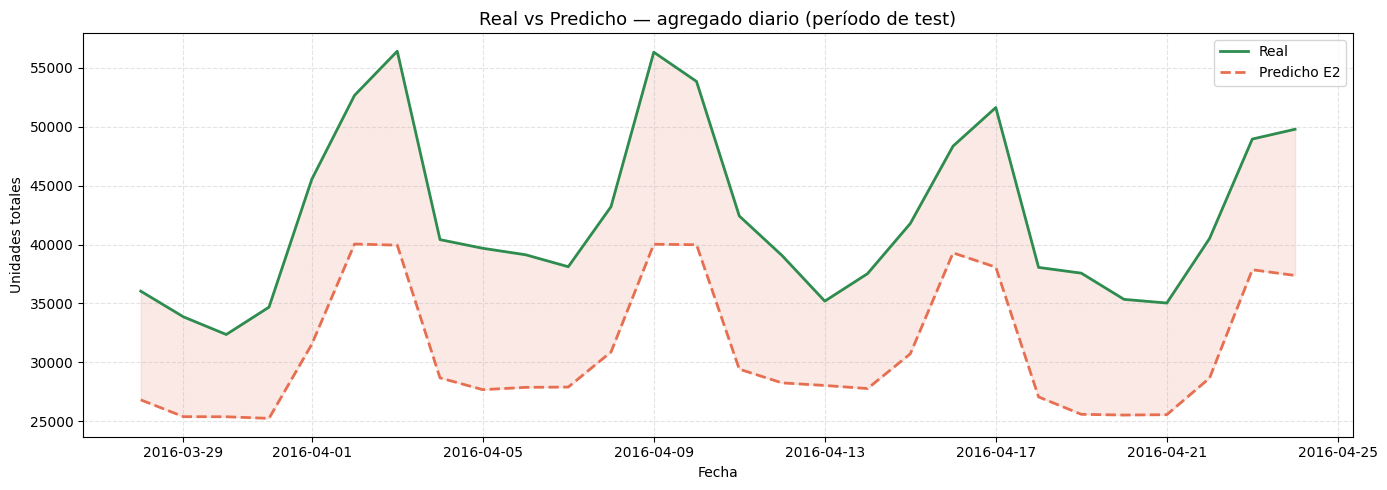

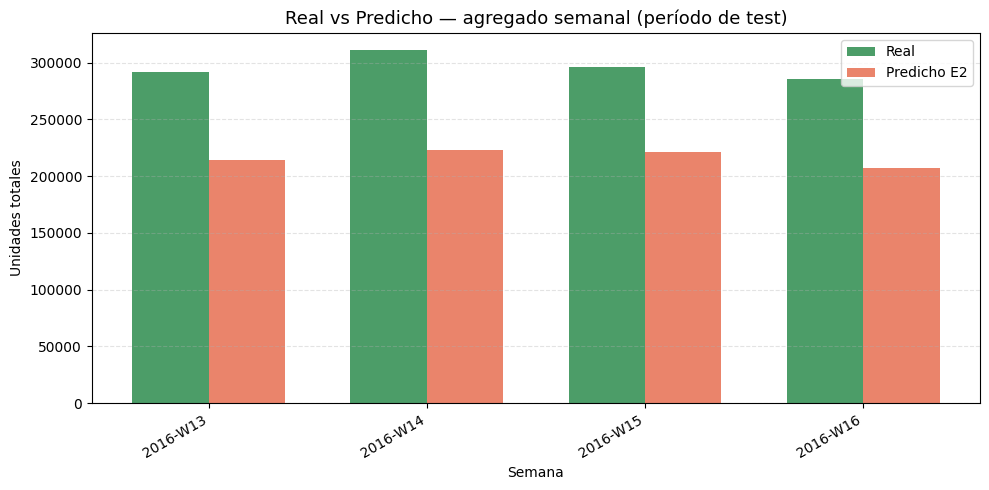

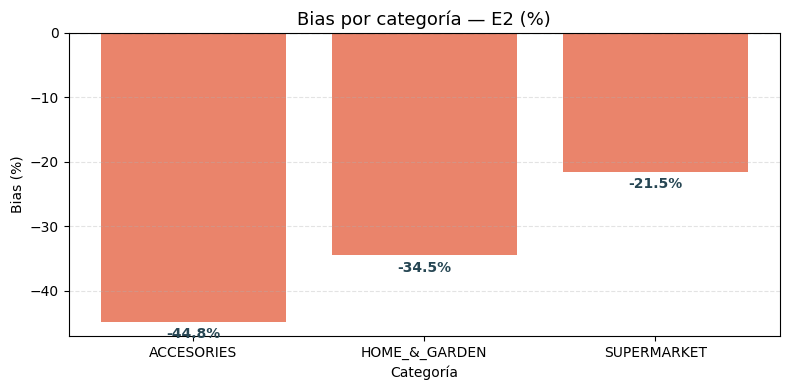

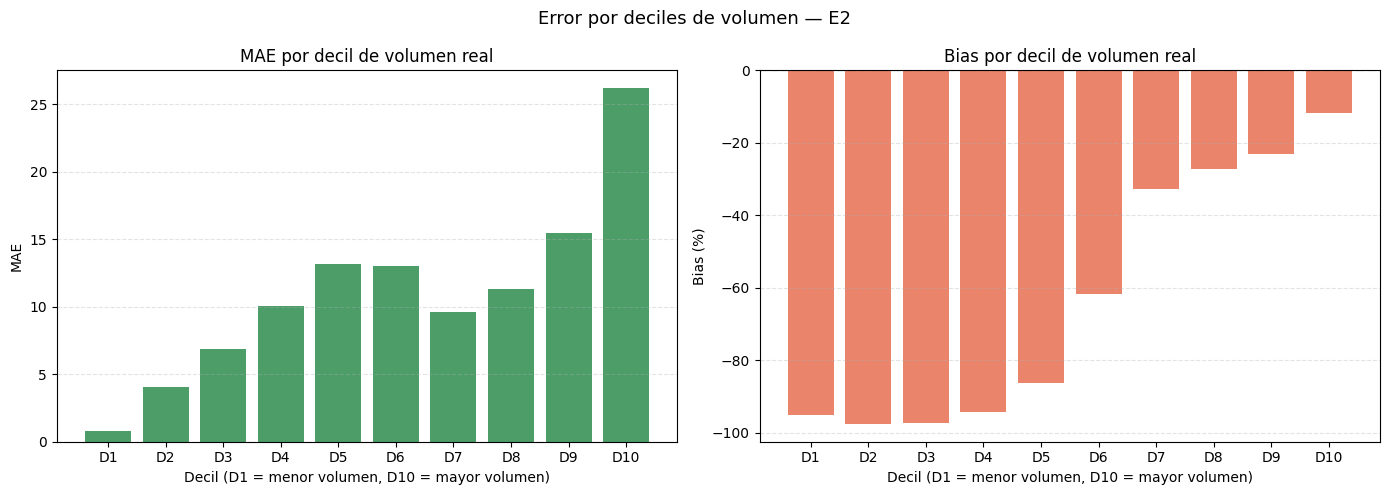


📌 Conclusión diagnóstico:
- Gráfico 1: muestra si el modelo va sistemáticamente por debajo día a día.
- Gráfico 2: muestra si el error semanal es aceptable para reposición.
- Gráfico 3: identifica qué categoría concentra el sesgo negativo.
- Gráfico 4: muestra si el modelo falla más en productos de mayor volumen.


In [25]:
# =============================================================================
# Diagnóstico E2 — 4 gráficos de negocio
# =============================================================================

df_diag = df_test_diag.copy()

# -----------------------------------------------------------------------------
# GRÁFICO 1 — Real vs Predicho agregado por día
# -----------------------------------------------------------------------------
df_daily_agg = (
    df_diag.groupby("date", as_index=False)[["units", "pred_E2"]]
    .sum()
    .sort_values("date")
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    df_daily_agg["date"],
    df_daily_agg["units"],
    color=COLORS["primary"],
    linewidth=2,
    label="Real"
)
ax.plot(
    df_daily_agg["date"],
    df_daily_agg["pred_E2"],
    color=COLORS["accent"],
    linewidth=2,
    linestyle="--",
    label="Predicho E2"
)
ax.fill_between(
    df_daily_agg["date"],
    df_daily_agg["units"],
    df_daily_agg["pred_E2"],
    alpha=0.15,
    color=COLORS["accent"]
)
ax.set_title("Real vs Predicho — agregado diario (período de test)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Unidades totales")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# GRÁFICO 2 — Real vs Predicho agregado por semana
# -----------------------------------------------------------------------------
iso = df_diag["date"].dt.isocalendar()
df_diag["iso_year"] = iso["year"].astype(int)
df_diag["iso_week"] = iso["week"].astype(int)
df_diag["yearweek"] = (
    df_diag["iso_year"].astype(str)
    + "-W"
    + df_diag["iso_week"].astype(str).str.zfill(2)
)

df_weekly_agg = (
    df_diag.groupby(["iso_year", "iso_week", "yearweek"], as_index=False)[["units", "pred_E2"]]
    .sum()
    .sort_values(["iso_year", "iso_week"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(df_weekly_agg))
width = 0.35

ax.bar(
    [i - width/2 for i in x],
    df_weekly_agg["units"],
    width=width,
    color=COLORS["primary"],
    alpha=0.85,
    label="Real"
)
ax.bar(
    [i + width/2 for i in x],
    df_weekly_agg["pred_E2"],
    width=width,
    color=COLORS["accent"],
    alpha=0.85,
    label="Predicho E2"
)

ax.set_xticks(list(x))
ax.set_xticklabels(df_weekly_agg["yearweek"], rotation=30, ha="right")
ax.set_title("Real vs Predicho — agregado semanal (período de test)", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("Unidades totales")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.35, axis="y")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# GRÁFICO 3 — Bias por categoría
# -----------------------------------------------------------------------------
df_bias_cat = (
    df_diag.groupby("category", as_index=False)[["units", "pred_E2"]]
    .sum()
)

df_bias_cat["bias_pct"] = (
    (df_bias_cat["pred_E2"] - df_bias_cat["units"])
    / (df_bias_cat["units"] + 1e-9) * 100
).round(2)

fig, ax = plt.subplots(figsize=(8, 4))

colors_bar = [
    COLORS["accent"] if b < 0 else COLORS["primary"]
    for b in df_bias_cat["bias_pct"]
]

ax.bar(
    df_bias_cat["category"],
    df_bias_cat["bias_pct"],
    color=colors_bar,
    alpha=0.85
)
ax.axhline(0, color=COLORS["dark"], linewidth=1.5, linestyle="--")
ax.set_title("Bias por categoría — E2 (%)", fontsize=13)
ax.set_xlabel("Categoría")
ax.set_ylabel("Bias (%)")
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

for i, row in df_bias_cat.iterrows():
    y = row["bias_pct"]
    va = "bottom" if y >= 0 else "top"
    offset = 0.8 if y >= 0 else -0.8
    ax.text(
        i,
        y + offset,
        f"{y:.1f}%",
        ha="center",
        va=va,
        fontsize=10,
        color=COLORS["dark"],
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# GRÁFICO 4 — Error por deciles de volumen
# -----------------------------------------------------------------------------
df_item_agg = (
    df_diag.groupby(["store_code", "item"], as_index=False)[["units", "pred_E2"]]
    .sum()
)

df_item_agg["decil"] = pd.qcut(
    df_item_agg["units"],
    q=10,
    labels=[f"D{i}" for i in range(1, 11)],
    duplicates="drop"
)

df_decil = (
    df_item_agg.groupby("decil", observed=True)
    .apply(lambda x: pd.Series({
        "MAE": np.mean(np.abs(x["units"] - x["pred_E2"])),
        "Bias_pct": ((x["pred_E2"].sum() - x["units"].sum()) / (x["units"].sum() + 1e-9)) * 100
    }))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    df_decil["decil"],
    df_decil["MAE"],
    color=COLORS["primary"],
    alpha=0.85
)
axes[0].set_title("MAE por decil de volumen real", fontsize=12)
axes[0].set_xlabel("Decil (D1 = menor volumen, D10 = mayor volumen)")
axes[0].set_ylabel("MAE")
axes[0].grid(True, linestyle="--", alpha=0.35, axis="y")

colors_decil = [
    COLORS["accent"] if b < 0 else COLORS["primary"]
    for b in df_decil["Bias_pct"]
]

axes[1].bar(
    df_decil["decil"],
    df_decil["Bias_pct"],
    color=colors_decil,
    alpha=0.85
)
axes[1].axhline(0, color=COLORS["dark"], linewidth=1.5, linestyle="--")
axes[1].set_title("Bias por decil de volumen real", fontsize=12)
axes[1].set_xlabel("Decil (D1 = menor volumen, D10 = mayor volumen)")
axes[1].set_ylabel("Bias (%)")
axes[1].grid(True, linestyle="--", alpha=0.35, axis="y")

plt.suptitle("Error por deciles de volumen — E2", fontsize=13)
plt.tight_layout()
plt.show()

print("\n📌 Conclusión diagnóstico:")
print("- Gráfico 1: muestra si el modelo va sistemáticamente por debajo día a día.")
print("- Gráfico 2: muestra si el error semanal es aceptable para reposición.")
print("- Gráfico 3: identifica qué categoría concentra el sesgo negativo.")
print("- Gráfico 4: muestra si el modelo falla más en productos de mayor volumen.")

<a id="calibracion"></a>

## Global calibration of E2

The E2 model was the best from a technical perspective, but it still had an underforecasting bias that was too high for direct use in replenishment.

In this block, I apply a simple global post-processing calibration to correct that bias without retraining the model.

The idea is practical:
if the model systematically predicts below the true total, a corrective multiplier can be applied to the final prediction.

[⬆ Back to table of contents](#indice)

In [26]:
# =============================================================================
# Audit 3 — Calibración global (E2 calibrado)
# =============================================================================
# Propósito:
#   - Aplicar multiplicador global para corregir bias sistemático
#   - Sin reentrenar: corrección en postprocesado
# Decisiones:
#   - Multiplicador = suma_real / suma_predicha
#   - En producción este multiplicador debe recalibrarse periódicamente
# =============================================================================

# Recuperar preds_E2 si ya no está en memoria
if "preds_E2" not in globals():
    e2_path = MODELS_DIR / "preds_E2.npy"
    if e2_path.exists():
        preds_E2 = np.load(str(e2_path))
    else:
        raise ValueError("No encuentro preds_E2. Ejecuta E2 o asegúrate de que existe preds_E2.npy.")

# Factor global de calibración
CALIBRATION_FACTOR = y_true_test.sum() / (preds_E2.sum() + 1e-9)
print(f"📊 Factor de calibración: {CALIBRATION_FACTOR:.4f}")

# Predicción calibrada
preds_E2_cal = np.clip(preds_E2 * CALIBRATION_FACTOR, 0, None)

# Métricas calibradas
metrics_E2_cal = calc_metrics(
    y_true_test,
    preds_E2_cal,
    "E2 — LightGBM + calibración"
)

# Tabla final sin hardcodes
if "df_metrics_final_test" not in globals():
    raise ValueError("No encuentro df_metrics_final_test. Ejecuta primero la tabla final de métricas.")

df_metrics_final = pd.concat(
    [
        df_metrics_final_test.copy(),
        pd.DataFrame([metrics_E2_cal])
    ],
    ignore_index=True
)

print("\n📊 Tabla completa de métricas:")
display(df_metrics_final)

# Base de diagnóstico
if "df_test_diag" not in globals():
    df_test_diag = df_panel.loc[mask_test, ["date", "store_code", "item", "category", "units"]].copy()
    df_test_diag["pred_E2"] = preds_E2

df_test_diag = df_test_diag.copy()
df_test_diag["pred_E2_cal"] = preds_E2_cal

# yearweek semanal
iso = df_test_diag["date"].dt.isocalendar()
df_test_diag["iso_year"] = iso["year"].astype(int)
df_test_diag["iso_week"] = iso["week"].astype(int)
df_test_diag["yearweek"] = (
    df_test_diag["iso_year"].astype(str)
    + "-W"
    + df_test_diag["iso_week"].astype(str).str.zfill(2)
)

# Ratio semanal antes y después
df_weekly_cal = (
    df_test_diag
    .groupby(["iso_year", "iso_week", "yearweek"], as_index=False)[["units", "pred_E2", "pred_E2_cal"]]
    .sum()
    .sort_values(["iso_year", "iso_week"])
    .reset_index(drop=True)
)

df_weekly_cal["ratio_raw"] = (df_weekly_cal["pred_E2"] / (df_weekly_cal["units"] + 1e-9)).round(3)
df_weekly_cal["ratio_cal"] = (df_weekly_cal["pred_E2_cal"] / (df_weekly_cal["units"] + 1e-9)).round(3)

print("\n📊 Ratio semanal antes y después de calibrar:")
display(df_weekly_cal[["yearweek", "units", "pred_E2", "pred_E2_cal", "ratio_raw", "ratio_cal"]])

# Guardado opcional
np.save(str(MODELS_DIR / "preds_E2_cal.npy"), preds_E2_cal)
df_metrics_final.to_csv(str(MODELS_DIR / "metrics_final_with_calibration.csv"), index=False)

print(f"\n📌 Conclusión:")
print(f"- Factor aplicado: ×{CALIBRATION_FACTOR:.4f}")
print(f"- El sesgo del modelo E2 se corrige en postproceso.")
print(f"- En producción: recalibrar el factor de forma periódica.")

📊 Factor de calibración: 1.3660

📊 Tabla completa de métricas:


,model,MAE,RMSE,WAPE (%),Bias (%),Underforecast (%)
0,E0a — Lag 7,1.2054,2.6601,86.9400,0.1800,26.3600
1,E0b — Media lags 7-28,1.0463,2.1880,75.4600,-0.6400,29.7100
2,E1 — LightGBM global,0.8886,2.0161,64.0900,-26.8500,35.1300
3,E2 — LightGBM + exógenas,0.8871,2.0100,63.9800,-26.8000,35.0500
4,E3 — LightGBM + clusters,0.8901,2.0148,64.2000,-26.8800,35.1700
5,E2 — LightGBM + calibración,0.9741,2.2004,70.2600,-0.0000,28.5700



📊 Ratio semanal antes y después de calibrar:


,yearweek,units,pred_E2,pred_E2_cal,ratio_raw,ratio_cal
0,2016-W13,291571,"214,310.8705","292,758.4371",0.7350,1.0040
1,2016-W14,310767,"223,000.9093","304,629.4269",0.7180,0.9800
2,2016-W15,296009,"221,548.6342","302,645.5528",0.7480,1.0220
3,2016-W16,285279,"207,601.0993","283,592.5831",0.7280,0.9940



📌 Conclusión:
- Factor aplicado: ×1.3660
- El sesgo del modelo E2 se corrige en postproceso.
- En producción: recalibrar el factor de forma periódica.


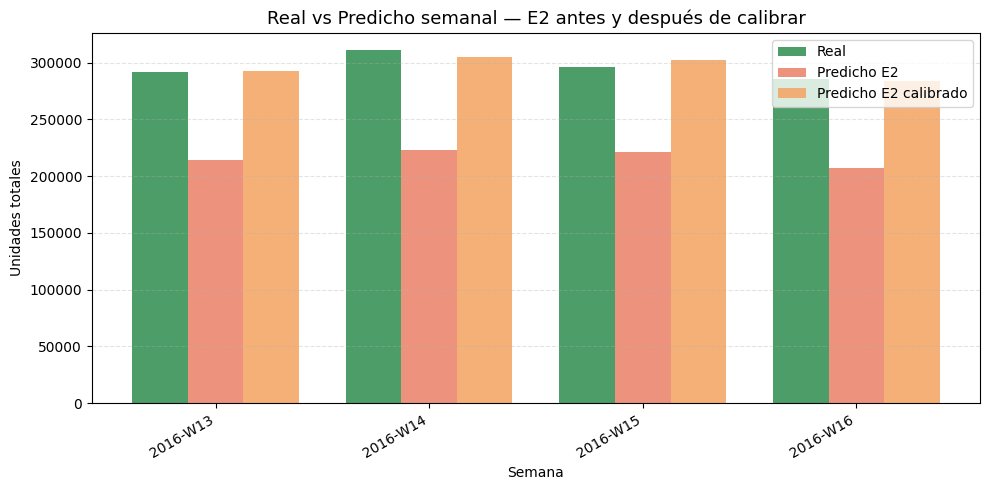

In [27]:
# =============================================================================
# Comparativa semanal — E2 antes vs después de calibrar
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(df_weekly_cal))
width = 0.26

ax.bar(
    [i - width for i in x],
    df_weekly_cal["units"],
    width=width,
    color=COLORS["primary"],
    alpha=0.85,
    label="Real"
)

ax.bar(
    x,
    df_weekly_cal["pred_E2"],
    width=width,
    color=COLORS["accent"],
    alpha=0.75,
    label="Predicho E2"
)

ax.bar(
    [i + width for i in x],
    df_weekly_cal["pred_E2_cal"],
    width=width,
    color=COLORS["secondary"],
    alpha=0.85,
    label="Predicho E2 calibrado"
)

ax.set_xticks(list(x))
ax.set_xticklabels(df_weekly_cal["yearweek"], rotation=30, ha="right")
ax.set_title("Real vs Predicho semanal — E2 antes y después de calibrar", fontsize=13)
ax.set_xlabel("Semana")
ax.set_ylabel("Unidades totales")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.35, axis="y")

plt.tight_layout()
plt.show()

<a id="cierre"></a>

## Executive closing

<div style="background-color:#2d8c4e;border-left:6px solid #264653;padding:14px;border-radius:10px">

### Answer to the business question

The **bottom-up** approach remains valid for DSMarket:
it is possible to forecast at **store × product × day** level and then aggregate to higher business levels.

### Main notebook result

During the test period, **E2 (LightGBM + known future exogenous variables)** was the best model from a technical perspective,
achieving the best aggregate metrics compared with the baselines and the rest of the tested variants.

However, the diagnostics revealed an important operational problem:
the model maintained a **systematic underforecasting bias** that was too high to use directly for replenishment.

### Final decision

For this reason, the best business solution is not the raw model,
but **calibrated E2**.

The global calibration applied in post-processing corrects the aggregate bias
and brings the weekly prediction much closer to the real demand level,
thereby reducing stockout risk.

### Implication for the next task

The conclusion of this notebook is twofold:

- **technical winning model:** E2
- **recommended operational model:** calibrated E2

From here, the next phase of the project is to translate this calibrated prediction
into a replenishment logic with **safety stock, service level and periodic monitoring**.

</div>

[⬆ Back to table of contents](#indice)